# SmartHVAC — EKF Runner (Standalone)

**8-State Extended Kalman Filter** on real sensor data.

This notebook is **completely independent** from the main SmartHVAC Colab pipeline.
- Reads: Kaggle Occupancy CSV + EPW weather file from Drive
- Runs: 8-state EKF (no humidity)
- Saves: 12 PNG plots to `Drive/SmartHVAC-Studio/EKF/results/`

In [24]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
import os

# Path to SmartHVAC-Studio on Drive
DRIVE_ROOT = '/content/drive/Othercomputers/My Laptop/SmartHVAC-Studio'

# Verify the EKF script exists
ekf_script = os.path.join(DRIVE_ROOT, 'EKF', 'Real_EKF.py')
assert os.path.exists(ekf_script), f'EKF script not found at {ekf_script}'
print(f'Found: {ekf_script}')

# Verify dataset exists
csv_path = os.path.join(DRIVE_ROOT, 'EKF', 'Datasets for EKF',
                        'Room Occupancy Estimation Keggle', 'Occupancy_Estimation.csv')
assert os.path.exists(csv_path), f'Dataset not found at {csv_path}'
print(f'Found: {csv_path}')

# Verify EPW exists
epw_path = os.path.join(DRIVE_ROOT, 'colab', 'weather',
                        'USA_IL_Chicago-OHare.Intl.AP.725300_TMY3.epw')
assert os.path.exists(epw_path), f'EPW not found at {epw_path}'
print(f'Found: {epw_path}')

print('\nAll files verified!')

Found: /content/drive/Othercomputers/My Laptop/SmartHVAC-Studio/EKF/Real_EKF.py
Found: /content/drive/Othercomputers/My Laptop/SmartHVAC-Studio/EKF/Datasets for EKF/Room Occupancy Estimation Keggle/Occupancy_Estimation.csv
Found: /content/drive/Othercomputers/My Laptop/SmartHVAC-Studio/colab/weather/USA_IL_Chicago-OHare.Intl.AP.725300_TMY3.epw

All files verified!


In [26]:
# Run the EKF with --save flag
# This saves 12 PNGs to SmartHVAC-Studio/EKF/results/
!python "{ekf_script}" --save

  SmartHVAC — 8-State EKF  (Real Data)

[1] Loading Kaggle CSV ...
    10129 rows | T_z 24.9-26.8 C | CO2 345-1270 ppm | Occ 0-3
[2] Loading EPW outdoor temp ...
    T_o -12.2--6.1 C (interpolated)
[3] EKF init ...
[4] Running EKF ...
    Done.

    Saved 12 plots to /content/drive/Othercomputers/My Laptop/SmartHVAC-Studio/EKF/results


In [27]:
# Verify outputs
results_dir = os.path.join(DRIVE_ROOT, 'EKF', 'results')
pngs = sorted([f for f in os.listdir(results_dir) if f.endswith('.png')])
print(f'Results in {results_dir}:')
for f in pngs:
    size_kb = os.path.getsize(os.path.join(results_dir, f)) / 1024
    print(f'  {f}  ({size_kb:.1f} KB)')
print(f'\nTotal: {len(pngs)} plots saved.')
print('\nDrive will auto-sync these to your local SmartHVAC-Studio/EKF/results/ folder.')
print('Open ekf.html in your browser and click Refresh to view them.')

Results in /content/drive/Othercomputers/My Laptop/SmartHVAC-Studio/EKF/results:
  01_zone_temp.png  (84.6 KB)
  02_zone_co2.png  (65.9 KB)
  03_occupancy.png  (45.8 KB)
  04_outdoor_temp.png  (29.0 KB)
  05_alpha_o.png  (39.2 KB)
  06_alpha_s.png  (38.1 KB)
  07_alpha_e.png  (40.6 KB)
  08_beta_o.png  (48.9 KB)
  09_beta_s.png  (53.9 KB)
  10_gamma_e.png  (40.6 KB)
  11_thermal_cap.png  (35.7 KB)
  12_UA.png  (41.4 KB)

Total: 12 plots saved.

Drive will auto-sync these to your local SmartHVAC-Studio/EKF/results/ folder.
Open ekf.html in your browser and click Refresh to view them.


--- 01_zone_temp.png ---


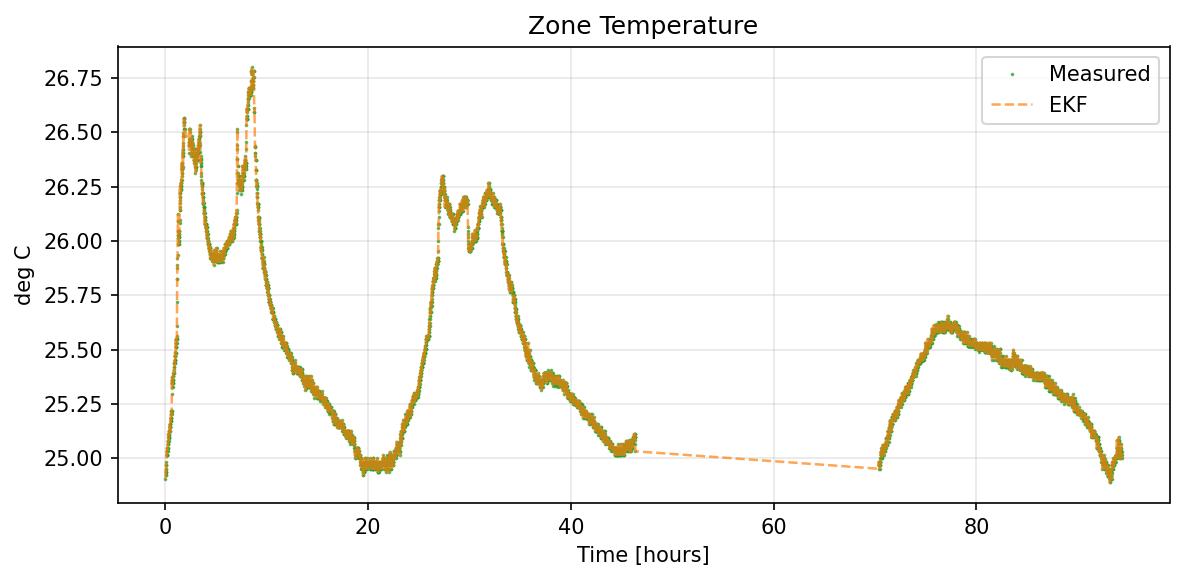

--- 02_zone_co2.png ---


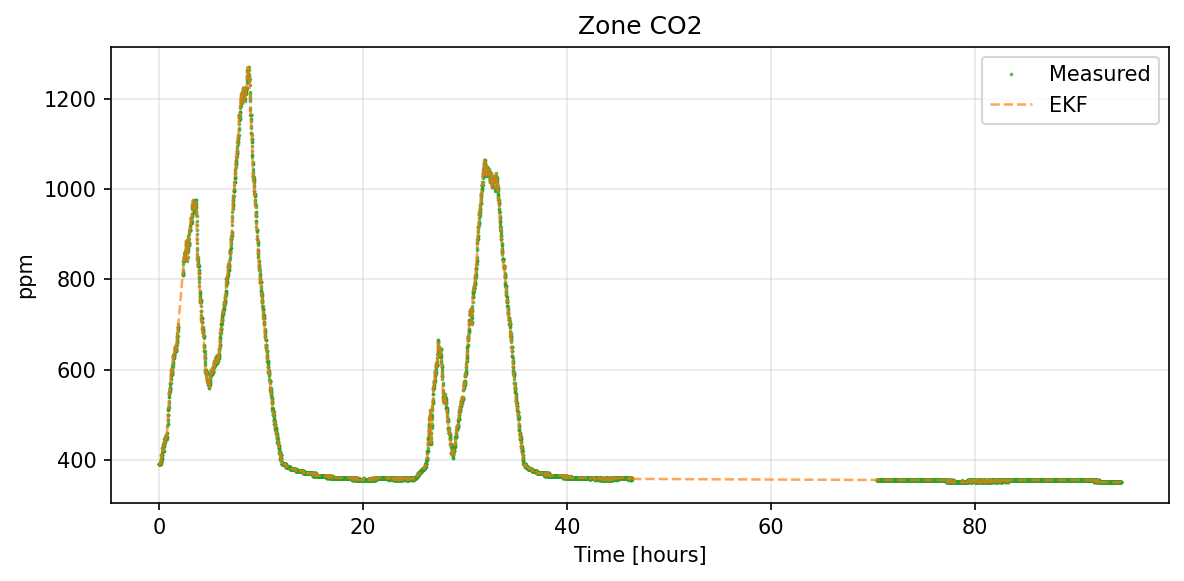

--- 03_occupancy.png ---


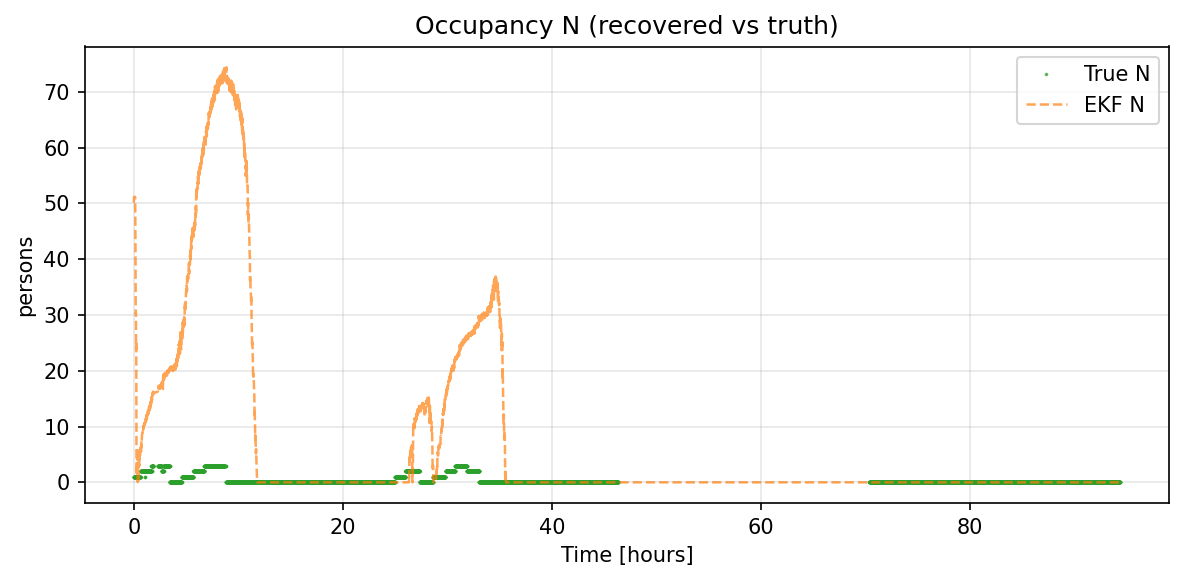

In [28]:
# Optional: Preview plots inline
from IPython.display import display, Image as IPImage
for f in pngs[:3]:  # show first 3
    print(f'--- {f} ---')
    display(IPImage(filename=os.path.join(results_dir, f), width=600))